In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def u_exact(x, t, eps = 0.1):
    alphas = [1, 4, 16]
    u = np.zeros_like(x, dtype = float)

    for alpha in alphas:
        u += np.exp(-eps * alpha**2 * t) * np.cos(alpha * x)

    return u

def gL(t):
    return u_exact(np.array([-1.0]), t)[0]

def gR(t):
    return u_exact(np.array([1.0]), t)[0]

def eta(x,eps = 0.1):
    return u_exact(x, 0, eps)

In [3]:
def FTCS(eps, T, Nx):
    xmin, xmax = -1, 1
    h = (xmax - xmin) / Nx
    x = np.linspace(xmin, xmax, Nx + 1)

    # stability
    k = 0.9 * h**2 / (2 * eps)
    Nt = int(T / k)
    k = T / Nt
    r = eps * k / h**2

    u = np.zeros((Nt + 1, Nx + 1))

    # initial condition from exact solution
    u[0, :] = eta(x, eps)

    for n in range(Nt):
        t = n * k

        # boundary conditions from exact solution
        u[n, 0] = gL(t)
        u[n, -1] = gR(t)

        for i in range(1, Nx):
            u[n+1, i] = (
                u[n, i]
                + r * (u[n, i+1] - 2*u[n, i] + u[n, i-1])
            )

        # enforce BC at next time level too
        u[n+1, 0] = gL(t + k)
        u[n+1, -1] = gR(t + k)

    return u, k, h, x

In [4]:
Nx_values = [25, 50, 100, 200, 400, 800]

dx_errors = []
dx_values = []

eps = 0.1
T = 1.0

for Nx in Nx_values:

    u, dt, dx, x = FTCS(eps, T, Nx)

    # exact solution at final time
    u_ex = u_exact(x, T, eps)

    # max norm error
    error = np.max(np.abs(u[-1, :] - u_ex))

    dx_errors.append(error)
    dx_values.append(dx)

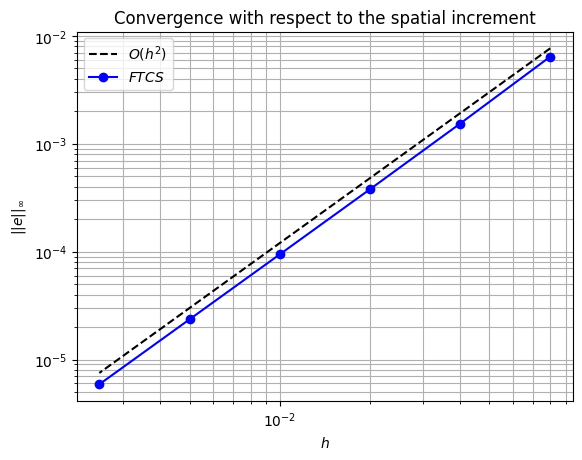

array([ 2.00035818, -0.05764964])

In [7]:
plt.loglog(dx_values,1.2*np.array(dx_values)**2, 'k--', label=r"$O(h^2)$")
plt.loglog(dx_values,dx_errors,'o-',color="blue", label=r"$FTCS$")
plt.title("Convergence with respect to the spatial increment")
plt.xlabel(r'$h$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dx_values[4:]),np.log(dx_errors[4:]),1)

In [8]:
Nt_values = [50, 100, 200, 400, 800, 1600]

dt_errors = []
dt_values = []

eps = 0.1
T = 1.0
xmin, xmax = -1, 1
L = xmax - xmin

r0 = 0.9 

for Nt in Nt_values:
    dt = T / Nt

    dx = np.sqrt(eps * dt / r0)
    Nx = int(L / dx)

    u, dt_used, dx_used, x = FTCS(eps, T, Nx)

    # exact solution
    u_ex = u_exact(x, T, eps)

    error = np.max(np.abs(u[-1, :] - u_ex))

    dt_errors.append(error)
    dt_values.append(dt)

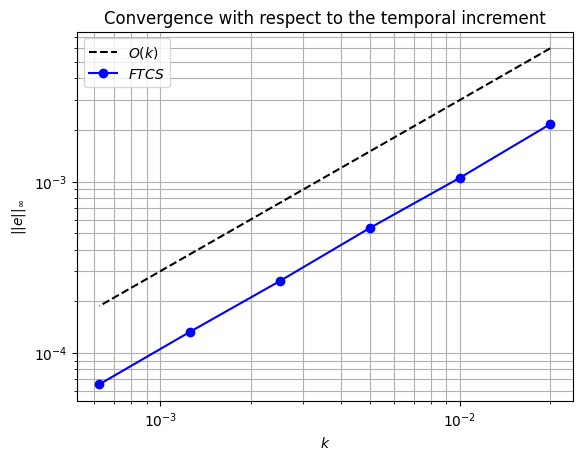

array([ 1.00091416, -2.24701874])

In [9]:
plt.loglog(dt_values,0.3*np.array(dt_values), 'k--', label=r"$O(k)$")
plt.loglog(dt_values,dt_errors,'o-',color="blue", label=r"$FTCS$")
plt.title("Convergence with respect to the temporal increment")
plt.xlabel(r'$k$')
plt.ylabel(r'$||e||_\infty$')
plt.grid(True, which = 'both')
plt.legend()
plt.show()

np.polyfit(np.log(dt_values[3:]),np.log(dt_errors[3:]),1)